In [1]:
import utils_inverse
import utils_plotting
%load_ext autoreload
%autoreload 2

# Use inverse model to find optimal emissions time series for CO<sub>2</sub>

## 1. Generate initial parameters, test backpropagation, and create baseline emulator

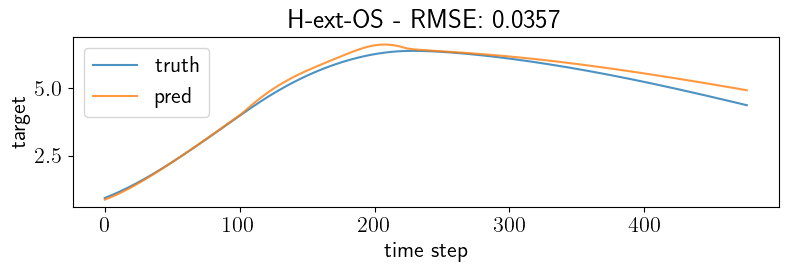

Getting gradient for historical...
	||grad BC||: 0.0
	||grad CH4||: 0.0
	||grad CO2||: 0.00019439701281953603
	||grad N2O||: 0.0
	||grad Sulfur||: 0.0


In [2]:
# Required to generate baseline parameters
agents        = ['CO2']       # Forcing agents included in temperatutre simulations
active_agents = ("CO2",)      # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]          # Dimension of neural network emulator
idx_demo      = 1             # Index of scenario to plot
test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False         # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

In [3]:
# Generate data for emulator evaluation
(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

In [4]:
# Baseline emulator parameters
save_path   = None#'checkpoints/co2_retuned/baseline_co2_only.pkl' # Location to save baseline data
verbose     = False # Flag to print NRMSE values from the baseline emulator

# Stage 6e's independently-tuned baseline hyperparameters (K held fixed at 400 to
# match the optimized emulator's K_inner; lr/weight_decay from a dedicated 500-run
# search - see data/SI_results/baseline_hp/k400_search/best_baseline_config_K400.json),
# replacing the old copied-from-the-optimized-emulator defaults (lr=0.05, wd=0.01).
baseline_K, baseline_lr, baseline_weight_decay = 400, 0.04803932015937589, 0.001

# Create baseline emulator
baseline_results, baseline_pred_delT, ground_truth_delT = utils_inverse.generate_and_eval_baseline_emulator(emis_dict_tier1_JAX,
                                                                                                            eval_sets, save_path=save_path,
                                                                                                            verbose=verbose, hidden_sizes=hidden_sizes,
                                                                                                            K=baseline_K, lr=baseline_lr, weight_decay=baseline_weight_decay)

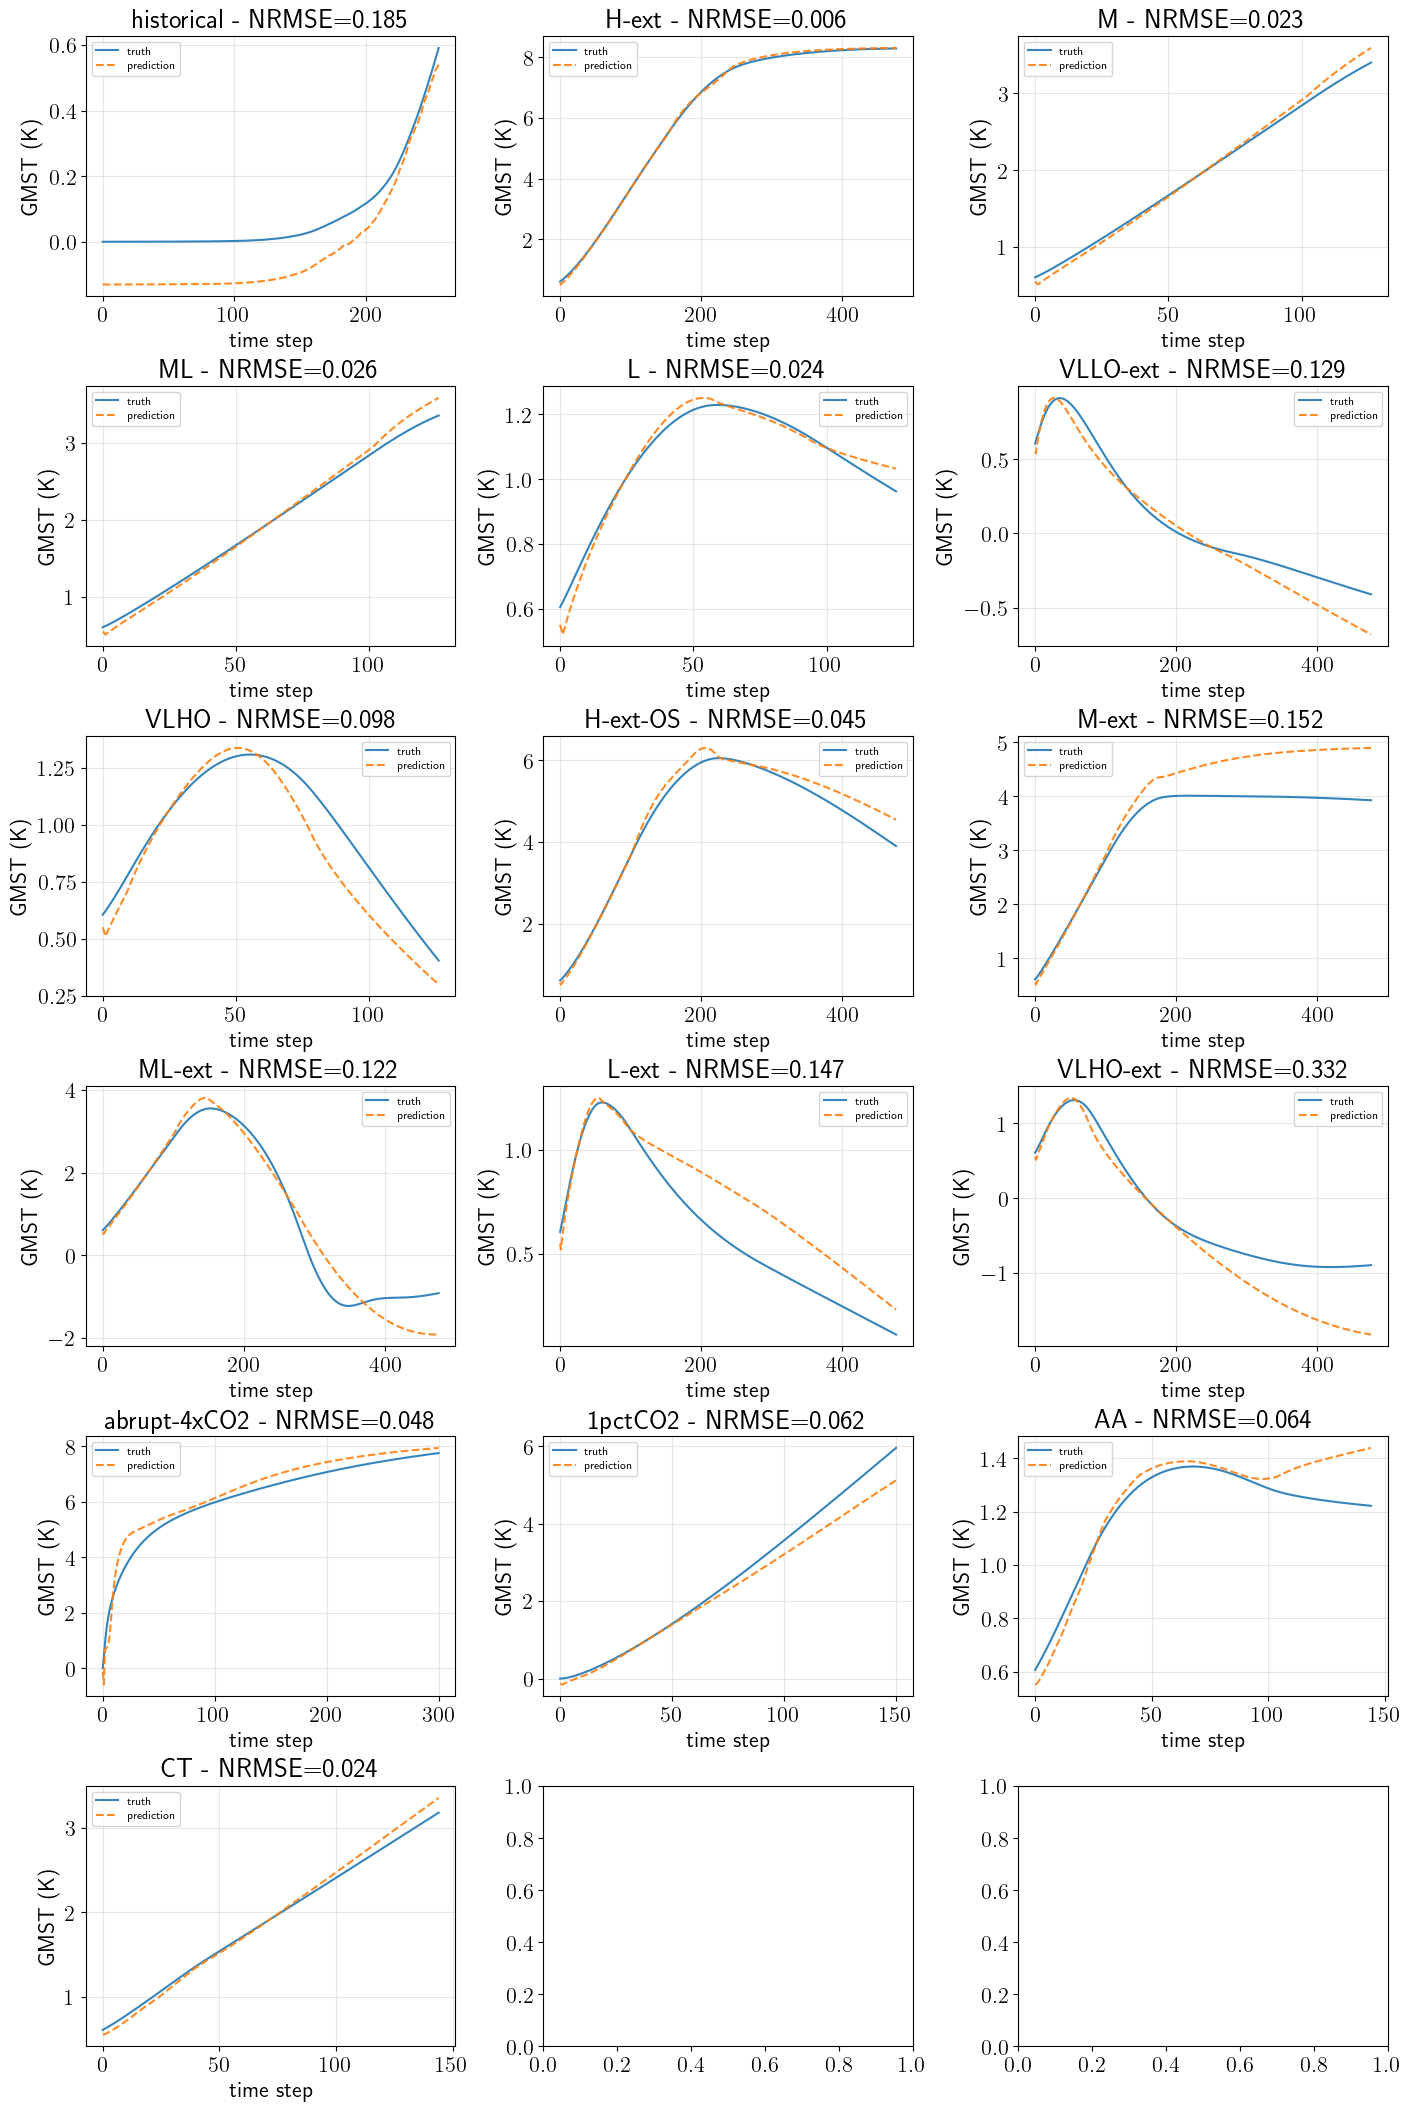

In [5]:
# Optional: plot predictions of baseline emulator
utils_plotting.plot_baseline_pred_delT(baseline_results, baseline_pred_delT, ground_truth_delT)

## 2. Optimize CO<sub>2</sub> emissions time series used in training

### 2a. Optimize for individual scenario (H-ext), starting from constant initial condition

In [6]:
# Compute migrated to scripts/3a_inverse_CO2_only.py (run standalone / scheduled) - this cell just loads the resulting checkpoint.
# Regenerated 2026-08-05 (Stage 0c) with Stage 0b's unified optimizer hyperparameters - checkpoints/co2_retuned/, not the stale checkpoints/co2/.
results_CO2_Hext_const = utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_sine_H-ext_co2_only.pkl')


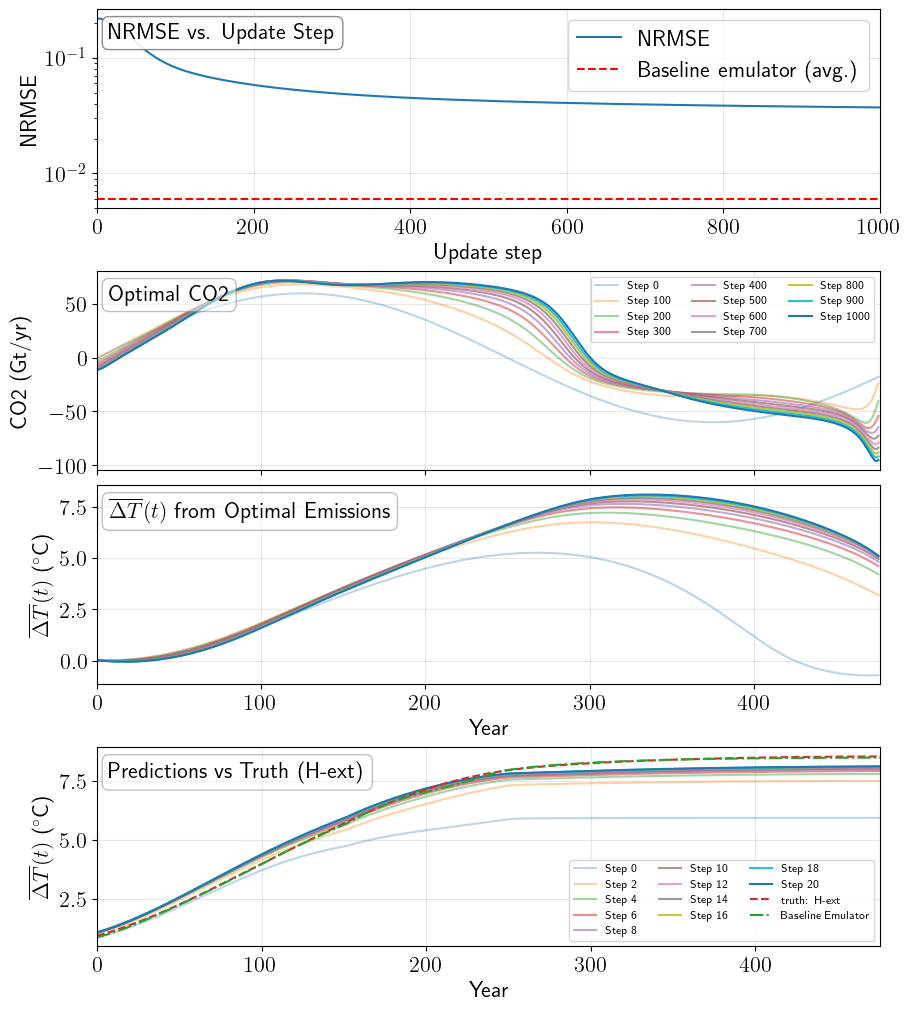

In [7]:
# Optional: plot results of optimization
predict_plot = 'H-ext'
utils_plotting.plot_inverse_results(
    results_CO2_Hext_const,
    baseline_results['Tier 1'][predict_plot],
    active_agents=active_agents,
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT['Tier 1'][predict_plot]
)

### 2b. Optimize training data for predictive skill over all evaluation sets

In [8]:
# Compute migrated to scripts/3a_inverse_CO2_only.py (run standalone / scheduled) - this cell just loads the resulting checkpoints.
# Regenerated 2026-08-05 (Stage 0c) with Stage 0b's unified optimizer hyperparameters - checkpoints/co2_retuned/, not the stale checkpoints/co2/.
results_CO2_dict = {
    'tier1': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_tier1_co2_only.pkl'),
    'tier2': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_tier2_co2_only.pkl'),
    'DECK': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_DECK_co2_only.pkl'),
    'CS3': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_CS3_co2_only.pkl'),
    'all': utils_inverse.load_inverse_ckpt('checkpoints/co2_retuned/inverse_constant_all_co2_only.pkl')
}


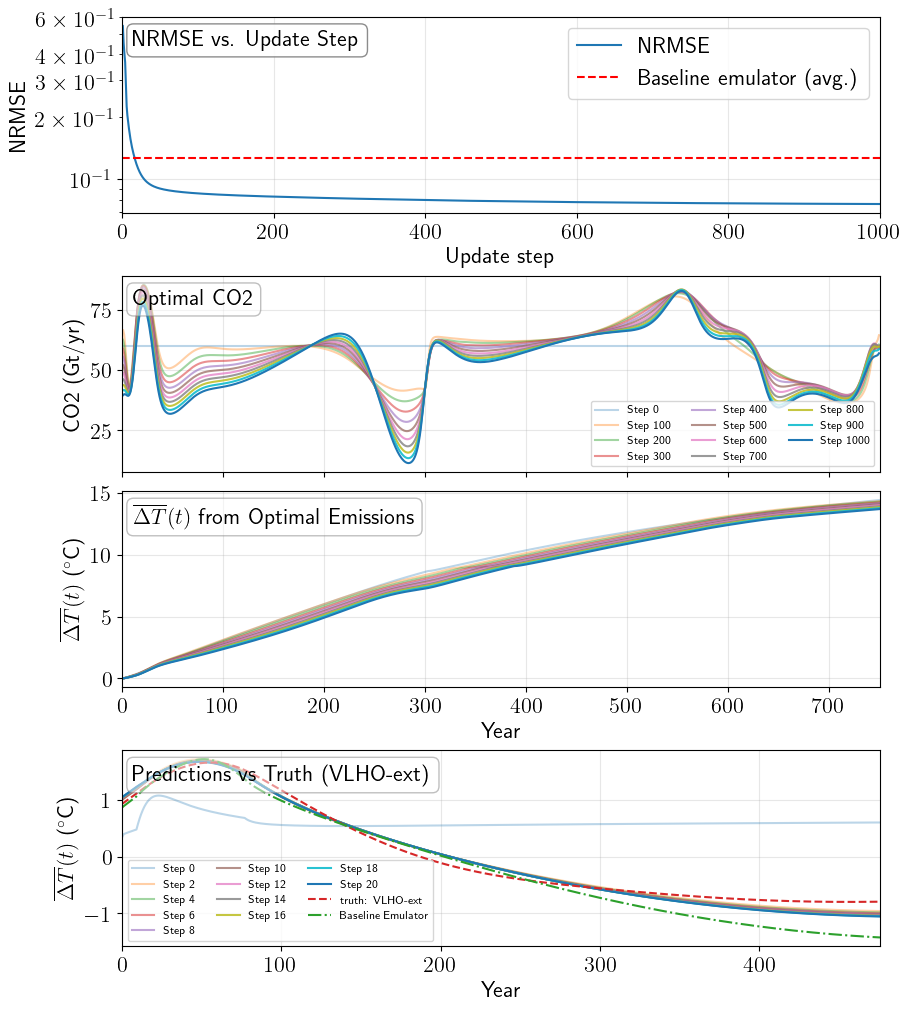

In [9]:
# Optional: plot results of optimization
## Plotting parameters
opt_test        = 'tier2'  # Evaluation set to plot optimized results for
baseline_test   = 'Tier 2' # Evaluation set to plot results for
predict_plot    = list(baseline_pred_delT[baseline_test].keys())[4]  # Individual scenario to plot predictions

utils_plotting.plot_inverse_results(
    results_CO2_dict[opt_test],
    baseline_results[baseline_test]['mean'],
    active_agents=active_agents,
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT[baseline_test][predict_plot]
)

### Calculate power spectrum of results
Not featured in manuscript; used as a backup slide for PhD defense

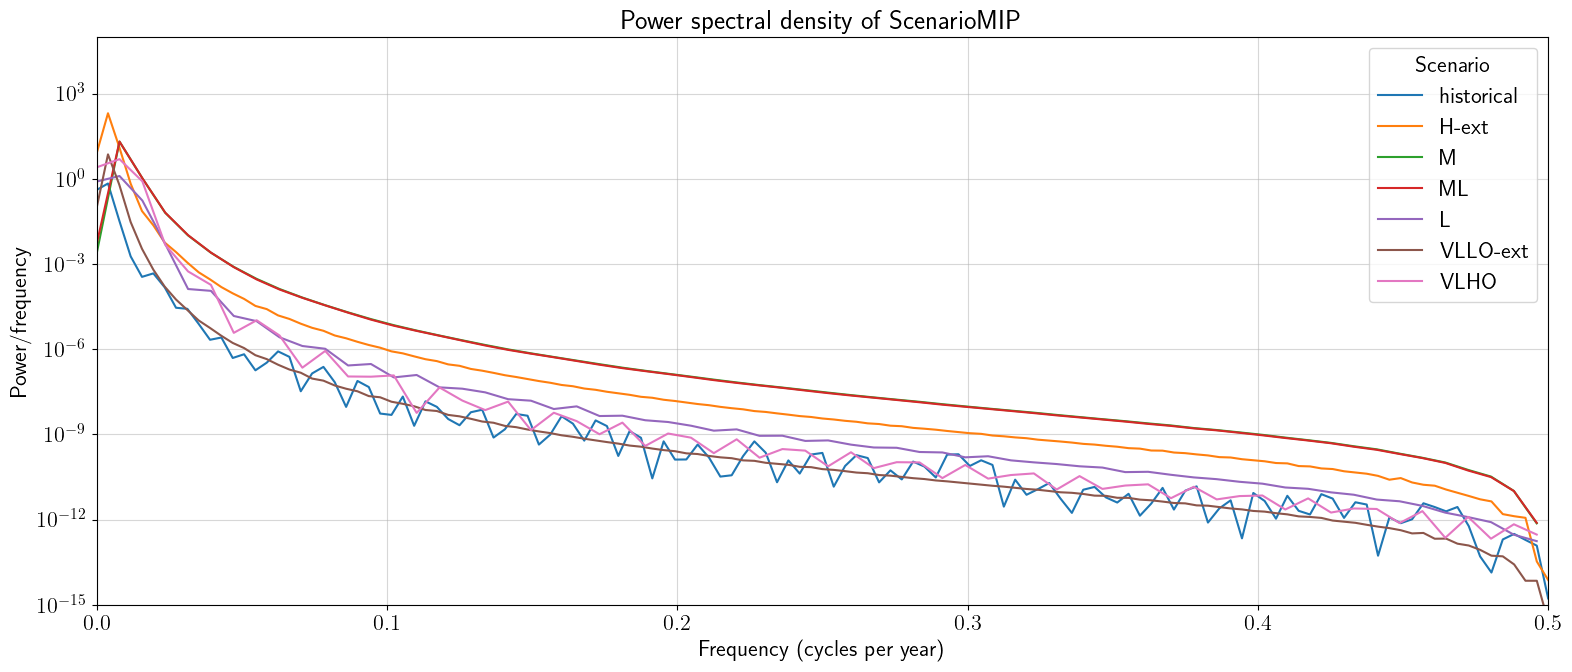

In [10]:
from scipy.signal import welch
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 7))
scen_set = 'Tier 1'
fs = 1
for name, ts in ground_truth_delT[scen_set].items():
    series_length = len(ts)
    current_nperseg = min(256, series_length)
    freqs, psd = welch(ts, fs=fs, nperseg=current_nperseg)

    # Plot using a logarithmic y-axis (standard for power spectra)
    plt.semilogy(freqs, psd, label=name)

# --- 3. Formatting ---
plt.xlabel('Frequency (cycles per year)')
plt.ylabel('Power/frequency')
plt.xlim([0, 0.5])
plt.ylim([1e-15, 1e5])
plt.legend(title='Scenario')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.title('Power spectral density of ScenarioMIP')
plt.tight_layout()
plt.show()

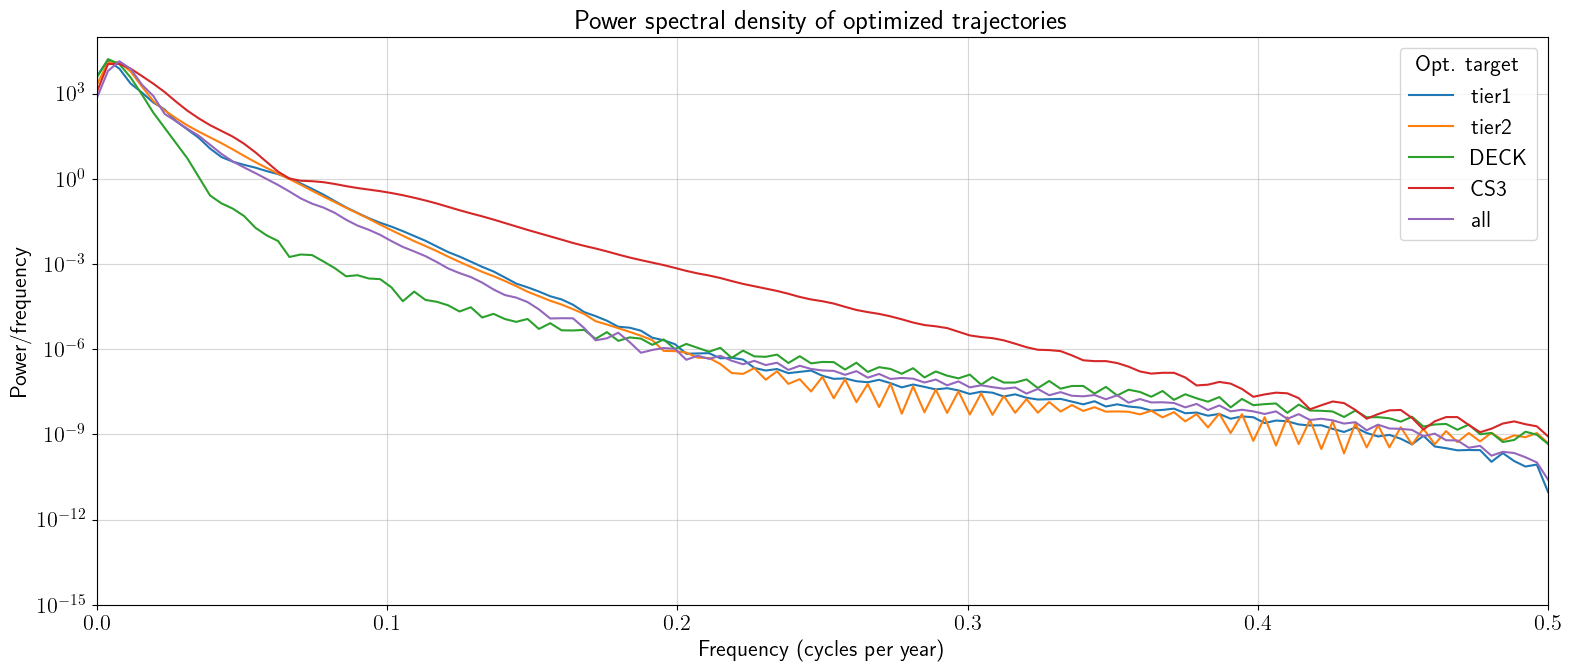

In [11]:
# Power spectrum of the optimized (rather than ground-truth) CO2 trajectories
plt.figure(figsize=(16, 7))
fs = 1

for name, res in results_CO2_dict.items():
    ts = res['U_traj'][-1]['CO2']
    series_length = len(ts)
    current_nperseg = min(256, series_length)
    freqs, psd = welch(ts, fs=fs, nperseg=current_nperseg)

    # Plot using a logarithmic y-axis (standard for power spectra)
    plt.semilogy(freqs, psd, label=name)

# --- 3. Formatting ---
plt.xlabel('Frequency (cycles per year)')
plt.ylabel('Power/frequency')
plt.xlim([0, 0.5])
plt.ylim([1e-15, 1e5])
plt.legend(title='Opt. target')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.title('Power spectral density of optimized trajectories')
plt.tight_layout()
plt.show()

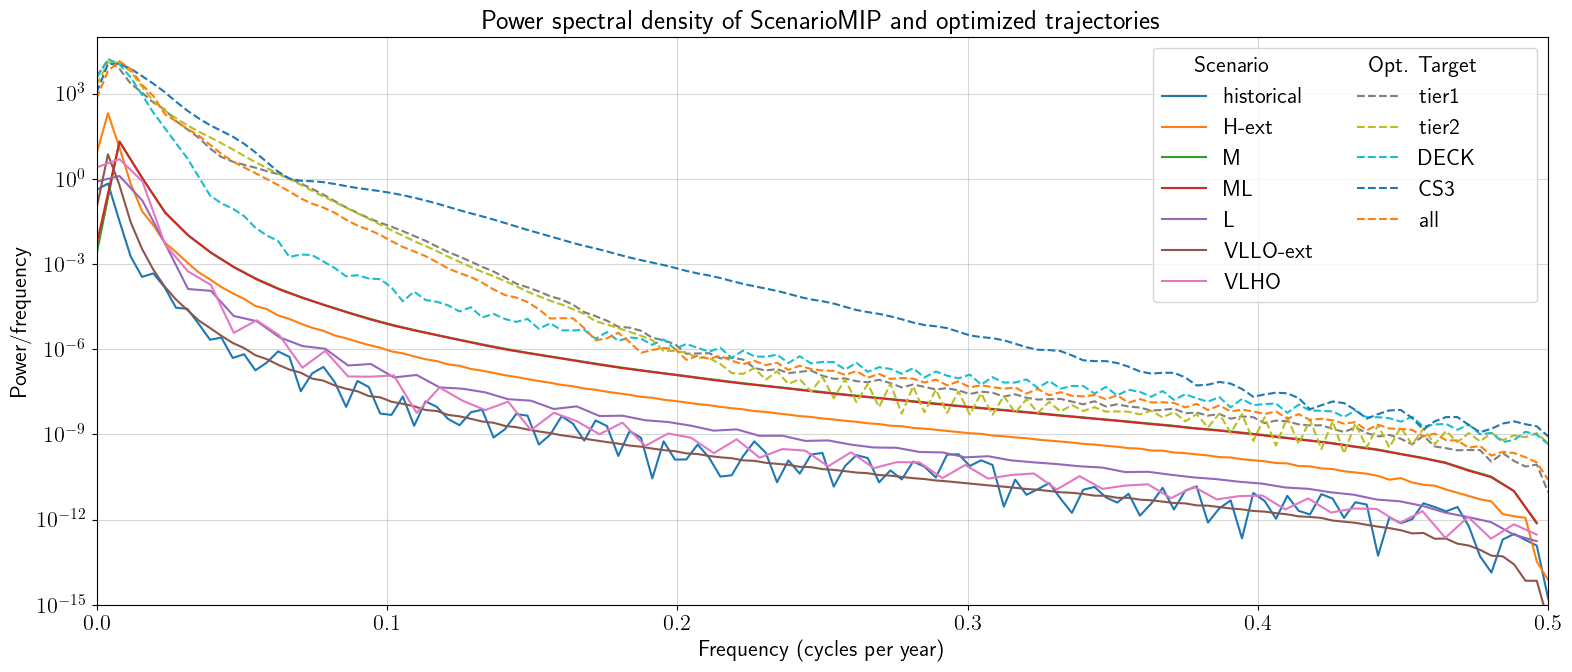

In [12]:
from matplotlib.lines import Line2D

plt.figure(figsize=(16, 7))
fs = 1
scen_set = 'Tier 1'

# 1. Plot Scenarios (Solid Lines)
handles_scen, labels_scen = [], []
for name, ts in ground_truth_delT[scen_set].items():
    series_length = len(ts)
    current_nperseg = min(256, series_length)
    freqs, psd = welch(ts, fs=fs, nperseg=current_nperseg)

    line, = plt.semilogy(freqs, psd, linestyle='-', label=name)
    handles_scen.append(line)
    labels_scen.append(name)

# 2. Plot Opt. Targets (Dashed Lines)
handles_opt, labels_opt = [], []
for name, res in results_CO2_dict.items():
    ts = res['U_traj'][-1]['CO2']
    series_length = len(ts)
    current_nperseg = min(256, series_length)
    freqs, psd = welch(ts, fs=fs, nperseg=current_nperseg)

    line, = plt.semilogy(freqs, psd, linestyle='--', label=name)
    handles_opt.append(line)
    labels_opt.append(name)

# 1. Create a transparent dummy line for the titles
title_proxy = Line2D([], [], color='none')

# 2. Insert the titles at the beginning of each list (using bold math-text)
handles_scen.insert(0, title_proxy)
labels_scen.insert(0, 'Scenario')

handles_opt.insert(0, title_proxy)
labels_opt.insert(0, 'Opt. Target')

# 3. Pad lists to the exact same length (Your existing code)
max_len = max(len(handles_scen), len(handles_opt))
dummy_line = Line2D([], [], color='none')

handles_scen += [dummy_line] * (max_len - len(handles_scen))
labels_scen += [''] * (max_len - len(labels_scen))
handles_opt += [dummy_line] * (max_len - len(handles_opt))
labels_opt += [''] * (max_len - len(labels_opt))

# Concatenate back-to-back
handles_combined = handles_scen + handles_opt
labels_combined = labels_scen + labels_opt

# 4. Formatting
plt.xlabel('Frequency (cycles per year)')
plt.ylabel('Power/frequency')
plt.xlim([0, 0.5])
plt.ylim([1e-15, 1e5])
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.title('Power spectral density of ScenarioMIP and optimized trajectories')

# Apply legend: Matplotlib will fill column 1 with handles_scen, then column 2 with handles_opt
leg = plt.legend(handles_combined, labels_combined, ncol=2)
shift_amount = -30
leg.get_texts()[0].set_position((shift_amount, 0))
leg.get_texts()[len(handles_scen)].set_position((shift_amount - 20, 0))

plt.tight_layout()
plt.show()